# Quantitative Framework: Real Estate Asset Pricing via Multi-Source Alternative Data
This notebook builds an end-to-end predictive framework for urban rental markets by programmatically ingesting, cleaning, and synthesizing disparate alternative datasets.

### Data Architecture & Engineering
1. **Primary Asset Data:** Granular residential real estate rental listings in Boston, MA.
2. **Alternative Geospatial Risk Layer:** Municipal incident reports aggregated at the ZIP code level to quantify local localized safety and public risk profiles.
3. **Macro Demographics Layer:** US Decennial Census data mapped via regular expressions to overlay localized macro demand parameters.

### Statistical Hygiene & Assumptions
- **Temporal Alignment:** ZIP-level socio-economic features (crime density and population factors) are assumed to remain structurally stable across the 2020–2025 cross-section.
- **Cross-Sectional Imputation:** Missing data profiles are addressed strictly within our cross-validation loop. Out-of-sample structural values are imputed dynamically using in-sample data partitions to eliminate any predictive look-ahead bias.

In [ ]:
install.packages("janitor")
install.packages("glmnet")
install.packages("caret")
install.packages("randomForest")
install.packages("rpart.plot")
install.packages("corrplot")
library(rpart.plot)
library(randomForest)
library(tidyr)
library(glmnet)
library(dplyr)
library(ggplot2)
library(janitor)
library(stringr)
library(caret)
library(recipes)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-1

In [ ]:
system("gdown 1-MzrLEflkWGOZMdRbeNbJaiRDXbUzSRH")
d <- read.csv('housing.csv')

system("gdown 1J-1B9rHRUYPqGYNhhsOCSpQHPTZavByX") #Crime data by zipcode
crime <- read.csv('Boston_Incidents.csv')

system("gdown 1JKgzS-8dVZRYruRnG2ykxshrwNoibKEw") #from https://data.census.gov/table?q=All+5-digit+ZIP+Code+Tabulation+Areas+fully/partially+contained+within+Boston+city,+Massachusetts&t=Population+Total
pop <- read.csv('DECENNIALDHC2020.P1-Data.csv') #2020 Census data (most recent)

d <- d %>%
  select(-url, -image_url, -nearby_cities, -X, -X.1) %>% #removing irrelevant or NA-filled columns
  filter(grepl("Boston, MA", address, ignore.case = TRUE)) #filtering for Boston, MA houses

crime <- crime %>%
  janitor::clean_names() %>%
  select(-objectid, -incident_number) %>%
  filter(zip_code != "", !is.na(zip_code)) %>%
  filter(year != 2025)

pop <- pop %>%
  slice(-1) %>%
  mutate(zip_code = stringr::str_extract(NAME, "\\b\\d{5}\\b")) %>%
  mutate(zipPop = P1_001N) %>%
  select(-GEO_ID, -X, -NAME, -P1_001N)

#EDA and Feature Engineering

##Data Cleaning

In [ ]:
## Extract the 5-digit zip code from the 'address' column in the housing data (d)

d <- d %>%
mutate(zip_code = stringr::str_extract(address, "\\b\\d{5}\\b")) %>%
filter(!is.na(zip_code))

## Aggregate the crime data to count the total number of incidents per zip code

crime_summary <- crime %>%
group_by(zip_code) %>%
summarize(incident_count = n(), .groups = 'drop')

## Perform a left join to attach the crime count to each house in the housing data. This results in our final data frame: merged_data.

merged_data <- d %>%
left_join(crime_summary, by = "zip_code") %>%
left_join(pop, by = "zip_code") %>%
filter(!is.na(zipPop)) #filtering out if there was no match

In [ ]:
## Change 'walk_score' and similar to fractions from character.

merged_data <- merged_data %>%
  mutate(across(c(walk_score, bike_score, transit_score),
                ~readr::parse_number(.x) / 100))

In [ ]:
## Recode more variables from character to numeric/integer.

merged_data <- merged_data %>%
  mutate(
    ## sqft: Remove commas and convert to integer
    sqft = as.integer(gsub(",", "", sqft)),

    ## estimated_monthly_payment: Remove '$' and '/mo' and convert to numeric
    estimated_monthly_payment = readr::parse_number(estimated_monthly_payment),

    ## price_per_sqft: Remove '$' and '/sqft' and convert to numeric
    price_per_sqft = readr::parse_number(price_per_sqft),

    ## fire_risk, wind_risk, air_risk, heat_risk: Extract the number inside the parentheses
    fire_risk = as.integer(str_extract(fire_risk, "(?<=\\()\\d+(?=/10\\))")),
    wind_risk = as.integer(str_extract(wind_risk, "(?<=\\()\\d+(?=/10\\))")),
    air_risk = as.integer(str_extract(air_risk, "(?<=\\()\\d+(?=/10\\))")),
    heat_risk = as.integer(str_extract(heat_risk, "(?<=\\()\\d+(?=/10\\))")),

    ## zipPop: Convert to integer
    zipPop = as.integer(zipPop),

    ## property_type: Convert to factor
    property_type = as.factor(property_type)


  )

In [ ]:
## year_built has an observation =9999 which we put to NA

merged_data <- merged_data %>%
  mutate(year_built = ifelse(year_built > 2025, NA, year_built))

merged_data <- merged_data |>
  mutate(age_building = 2025 - year_built) ## Create variable 'age_building' from 'year_built'

## Drop year_built
merged_data <- merged_data %>% select(-address, -year_built)

In [ ]:
## Change 'price' to number
merged_data <- merged_data %>%
  mutate(price = as.character(price)) %>% # Convert to character first
  mutate(price = readr::parse_number(price))

## Change 'zipcode' to factor
merged_data <- merged_data %>% mutate(zip_code = as.factor(zip_code))

## Change school distance to numeric
merged_data$middle_school_distance[merged_data$middle_school_distance == ""] <- NA
merged_data$middle_school_distance <- as.numeric(gsub(" mi", "", merged_data$middle_school_distance))

merged_data$high_school_distance[merged_data$high_school_distance == ""] <- NA
merged_data$high_school_distance <- as.numeric(gsub(" mi", "", merged_data$high_school_distance))

merged_data$elementary_school_distance[merged_data$elementary_school_distance == ""] <- NA
merged_data$elementary_school_distance <- as.numeric(gsub(" mi", "", merged_data$elementary_school_distance))

In [ ]:
## Drop irrelevant variables
merged_data <- merged_data |>
  select(-region, -property_history, -high_school_name, -middle_school_name, -elementary_school_name)

## Check for frequency distributions and identify missing values (NAs) in key property features.
table(merged_data$sqft_lot, useNA = "ifany")

table(merged_data$appliances, useNA = "ifany")

table(merged_data$parking_total_spaces, useNA = "ifany")


                 , sqft      . sqft  0.26 Acres  0.27 Acres   0.29 sqft 
        460           2           1           1           1           1 
  0.67 sqft     02 sqft  1,006 sqft  1,029 sqft  1,042 sqft  1,043 sqft 
          1           1           1           1           1           1 
 1,108 sqft  1,196 sqft  1,216 sqft  1,265 sqft  1,268 sqft  1,306 sqft 
          1           1           1           1           1           1 
 1,322 sqft  1,377 sqft  1,432 sqft  1,440 sqft  1,500 sqft  1,520 sqft 
          1           1           1           1           1           1 
 1,522 sqft  1,534 sqft  1,560 sqft  1,620 sqft  1,646 sqft  1,666 sqft 
          1           1           1           1           1           1 
 1,690 sqft  1,750 sqft  1,810 sqft  1,834 sqft  1,953 sqft  1,978 sqft 
          1           1           1           2           1           1 
     2 sqft  2,000 sqft  2,079 sqft  2,150 sqft  2,253 sqft  2,271 sqft 
          1           1           1           1   


       dishwasher; range; microwave             dishwasher; range; oven 
                                  1                                   3 
     dishwasher; refrigerator; oven     dishwasher; refrigerator; range 
                                  1                                   3 
          dishwasher; washer; range         disposal; dishwasher; range 
                                  7                                   1 
                       dryer; range                dryer; range; washer 
                                  1                                   1 
            freezer; range; cooktop        microwave; dishwasher; range 
                                  1                                   2 
microwave; dishwasher; refrigerator                    microwave; range 
                                  4                                   1 
             microwave; range; oven       microwave; range; wine cooler 
                                  1               


   1    2    3    4    5    6 <NA> 
 177   68   12    8    4    1  258 

In [ ]:
## Drop more NA-filled variables
merged_data = merged_data %>%
  select(-parking_garage_spaces, -parking_total_spaces)

In [ ]:
## Final Data Cleaning
merged_data <- merged_data %>%
  select(-matches("risk$"), ## fire_risk, flood risk and similar contain the same information as 'zip_code'
         -parking_parking_features,
         -utilities_Electric,
         -utilities_Sewer,
         -utilities_Water,
         -parking_uncovered_spaces,
         -high_school_distance, ## very high percentage of NAs
         -price_per_sqft) ## price_per_sqft is too collinear with the outcome variable estimated_monthly_payment

**Renaming some variables**

In [ ]:
## In the data frame 'merged_data':
merged_data <- merged_data %>%
  # 1. Convert the column into multiple rows based on the delimiter ('; ')
  separate_rows(appliances, sep = ";\\s*") %>%
  # 2. Clean up any leading/trailing spaces that might remain
  mutate(appliances = trimws(appliances))

# Pivot the temporary data to wide format
merged_data <- merged_data %>%
  # Create a temporary value column set to 1
  mutate(has_feature = 1) %>%

  distinct() %>% # Removes exact duplicate rows

  pivot_wider(
    names_from = appliances,
    values_from = has_feature,
    values_fill = 0
)

In [ ]:
##Creating dummies from 'interior features' variable (one for each variable).

# Pull all elements of interior_features into a clean vector
features <- merged_data$interior_features |>
  str_split(";\\s*") |>
  unlist() |>
  str_to_lower() |>
  str_trim()

# Drop empty strings but KEEP NA logic separate
features <- features[features != "" & !is.na(features)]

# Make them valid column names
features <- make.names(unique(features))

features
length(features)

#Now to run

for (f in features) {
  colname <- paste0("int_", f)

  merged_data[[colname]] <-
    ifelse(
      is.na(merged_data$interior_features),
      NA,  # DO NOT touch NAs
      as.integer(
        stringr::str_detect(
          stringr::str_to_lower(merged_data$interior_features),
          stringr::fixed(gsub("\\.", " ", f))
        )
      )
    )
}

[1] "fireplace"           "marble"              "hardwood.floors"    
 [4] "stainless.steel"     "granite.countertops" "bay.window"         
 [7] "walk.in.closet"      "carpet"              "crown.molding"      
[10] "hardwood.floor"      "skylight"            "vaulted.ceiling"    
[13] "laminate"            "tile.floor"          "built.in.shelves"   
[16] "tile.floors"

[1] 16

In [ ]:
## Drop more NA-filled or perfectly collinear variables
merged_data <- merged_data %>%
  select(-sqft_lot, -price, -int_walk.in.closet, -int_built.in.shelves)

## New regressor: crime incidents per capita
crime_pc <- merged_data$incident_count / merged_data$zipPop

merged_data <- merged_data %>%
  select(-incident_count)

In [ ]:
## One condo has been coded as property_type == 'Condo'. This corrects that.
merged_data <- merged_data %>%
  mutate(property_type = recode(property_type,
                                "Condo" = "condo",
                                "TOWNHOUSE" = "townhouse"))

In [ ]:
merged_data <- merged_data %>%
  rename(wine_cooler = `wine cooler`)

##Visualisation

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


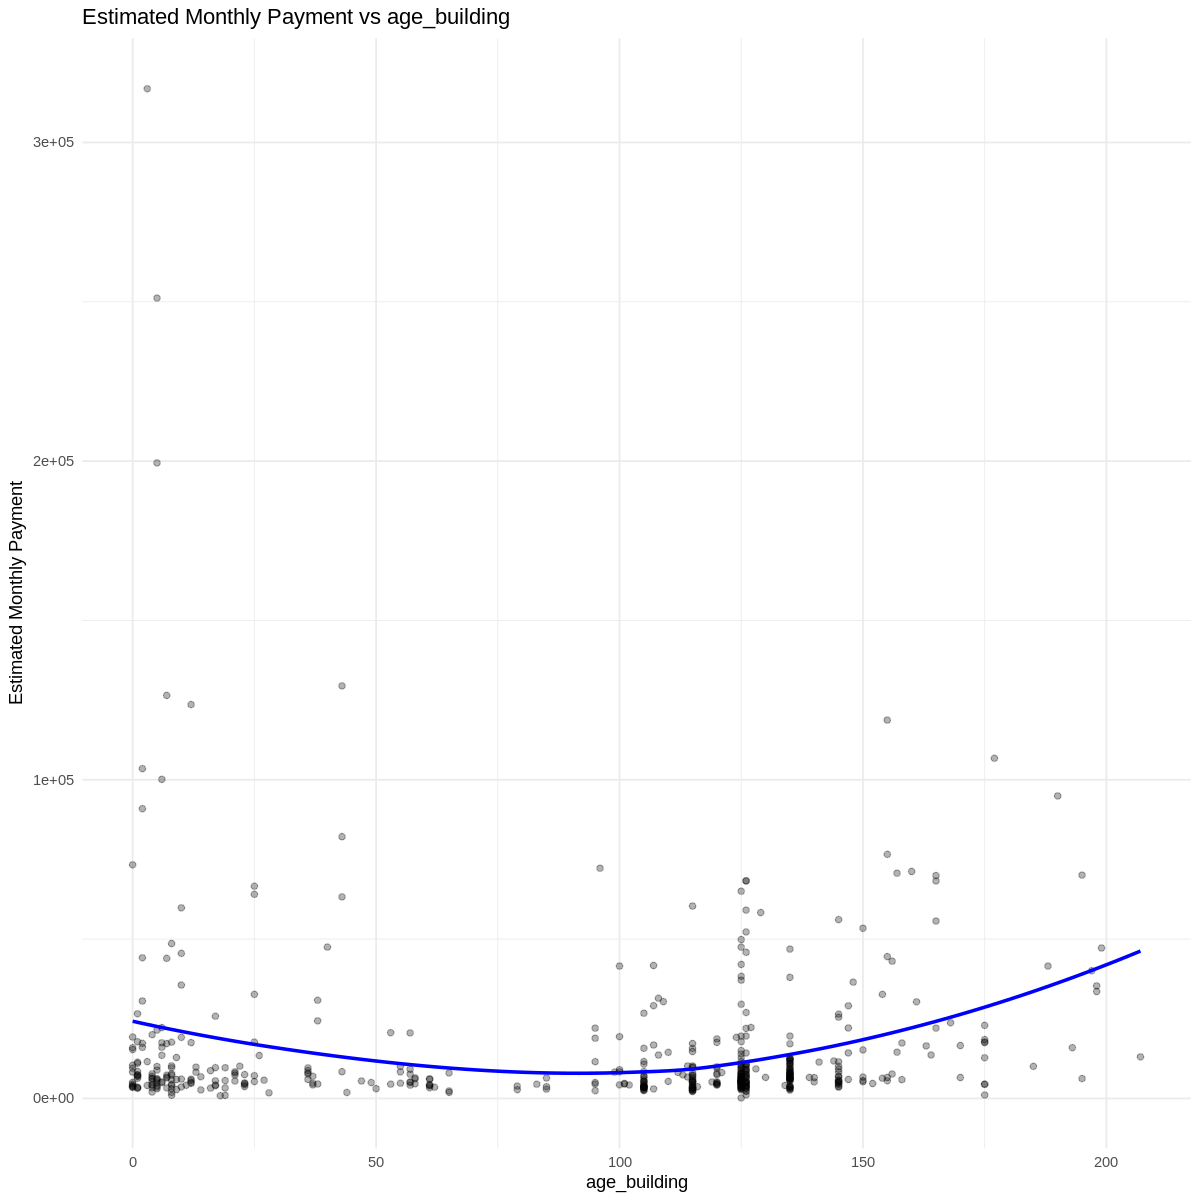

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 71 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 71 rows containing missing values or values outside the scale range
(`geom_point()`).”


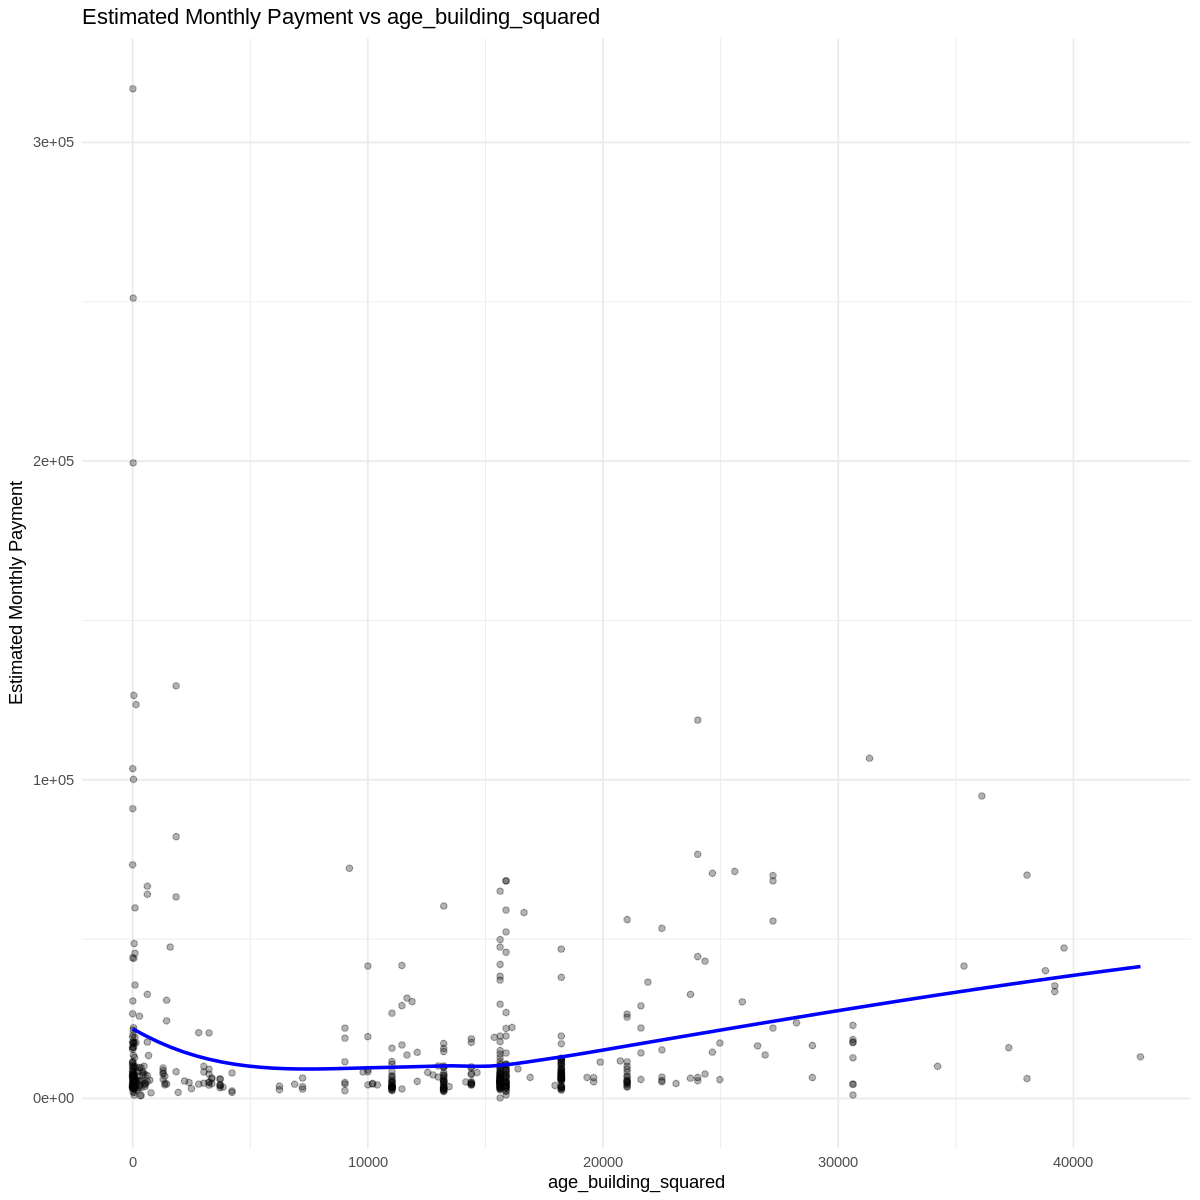

`geom_smooth()` using formula = 'y ~ x'


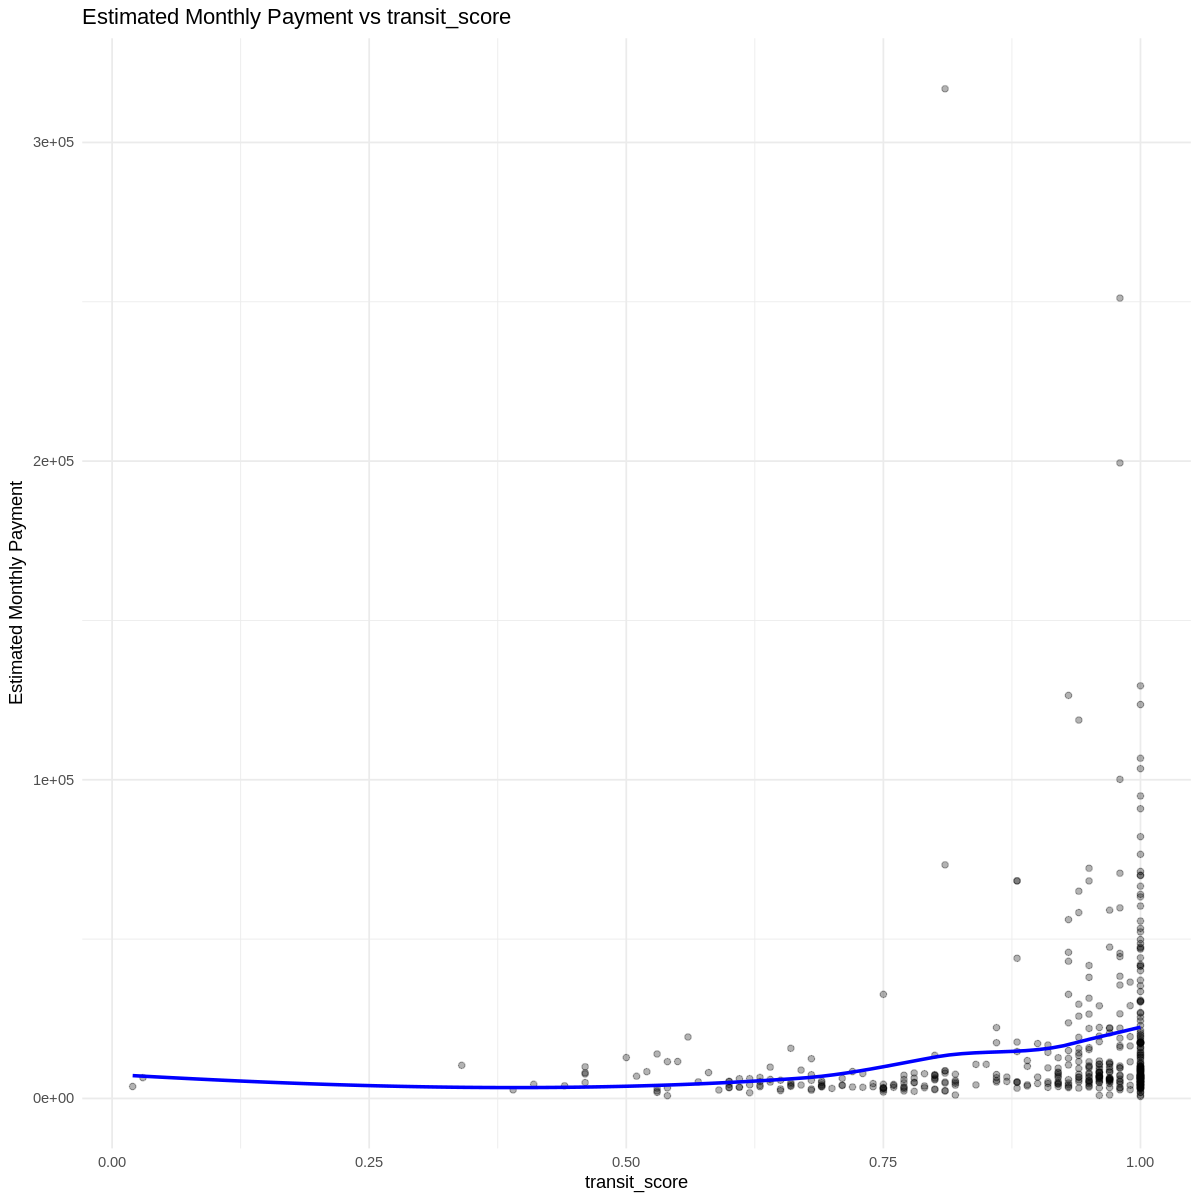

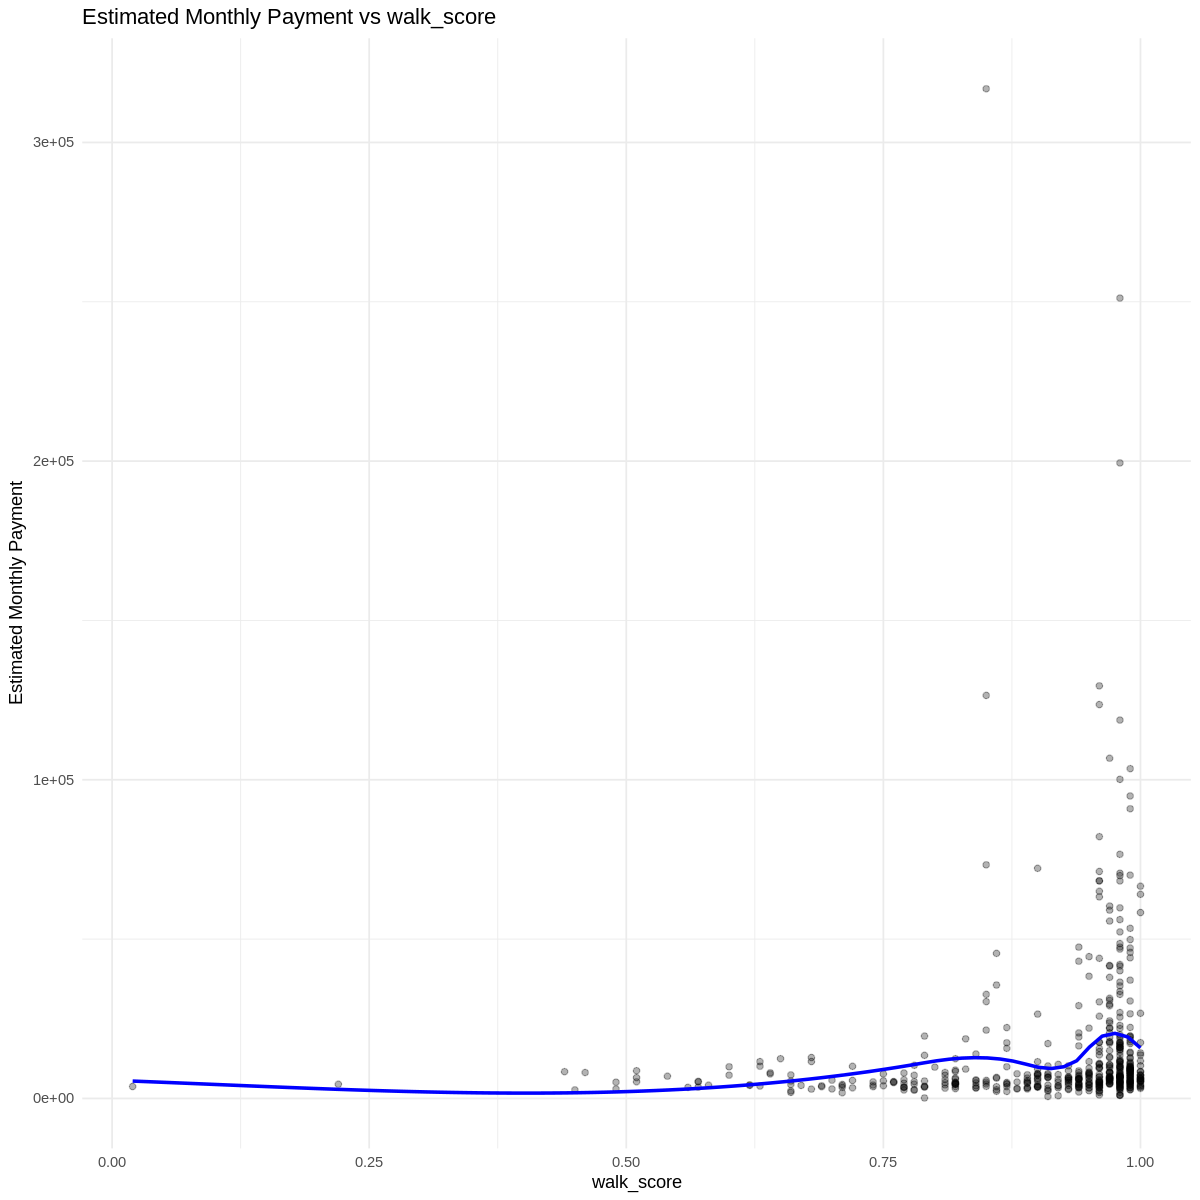

In [ ]:
## We graph the following predictors (against the monthly payments) which may display nonlinearities, thus justifying the need for Random Forest.

merged_data <- merged_data %>%
  mutate(age_building_squared = age_building^2)

vars_1 <- c(
  "age_building",
  "age_building_squared",
  "transit_score",
  "walk_score"
)

for (v in vars_1) {
  p <- ggplot(merged_data, aes_string(x = v, y = "estimated_monthly_payment")) +
    geom_point(alpha = 0.3) +
    geom_smooth(method = "loess", se = FALSE, color = "blue") +
    labs(
      title = paste("Estimated Monthly Payment vs", v),
      x = v,
      y = "Estimated Monthly Payment"
    ) +
    theme_minimal()

  print(p)
}

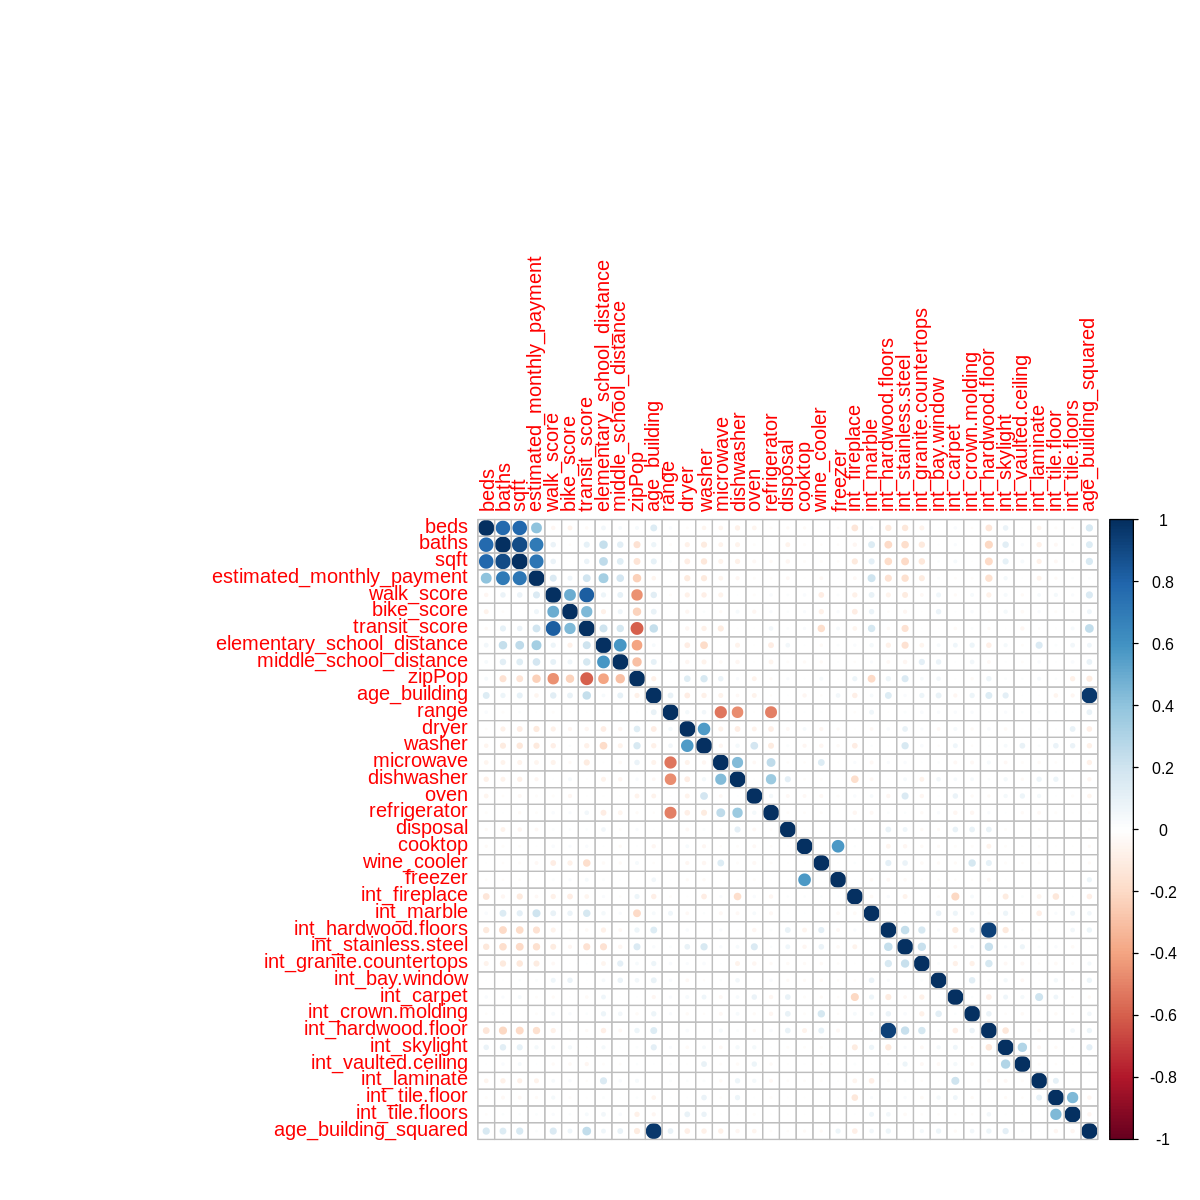

In [ ]:
merged_data |>
  select(where(is.numeric)) |>
  cor(use = "pairwise.complete.obs") |>
  corrplot::corrplot()

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


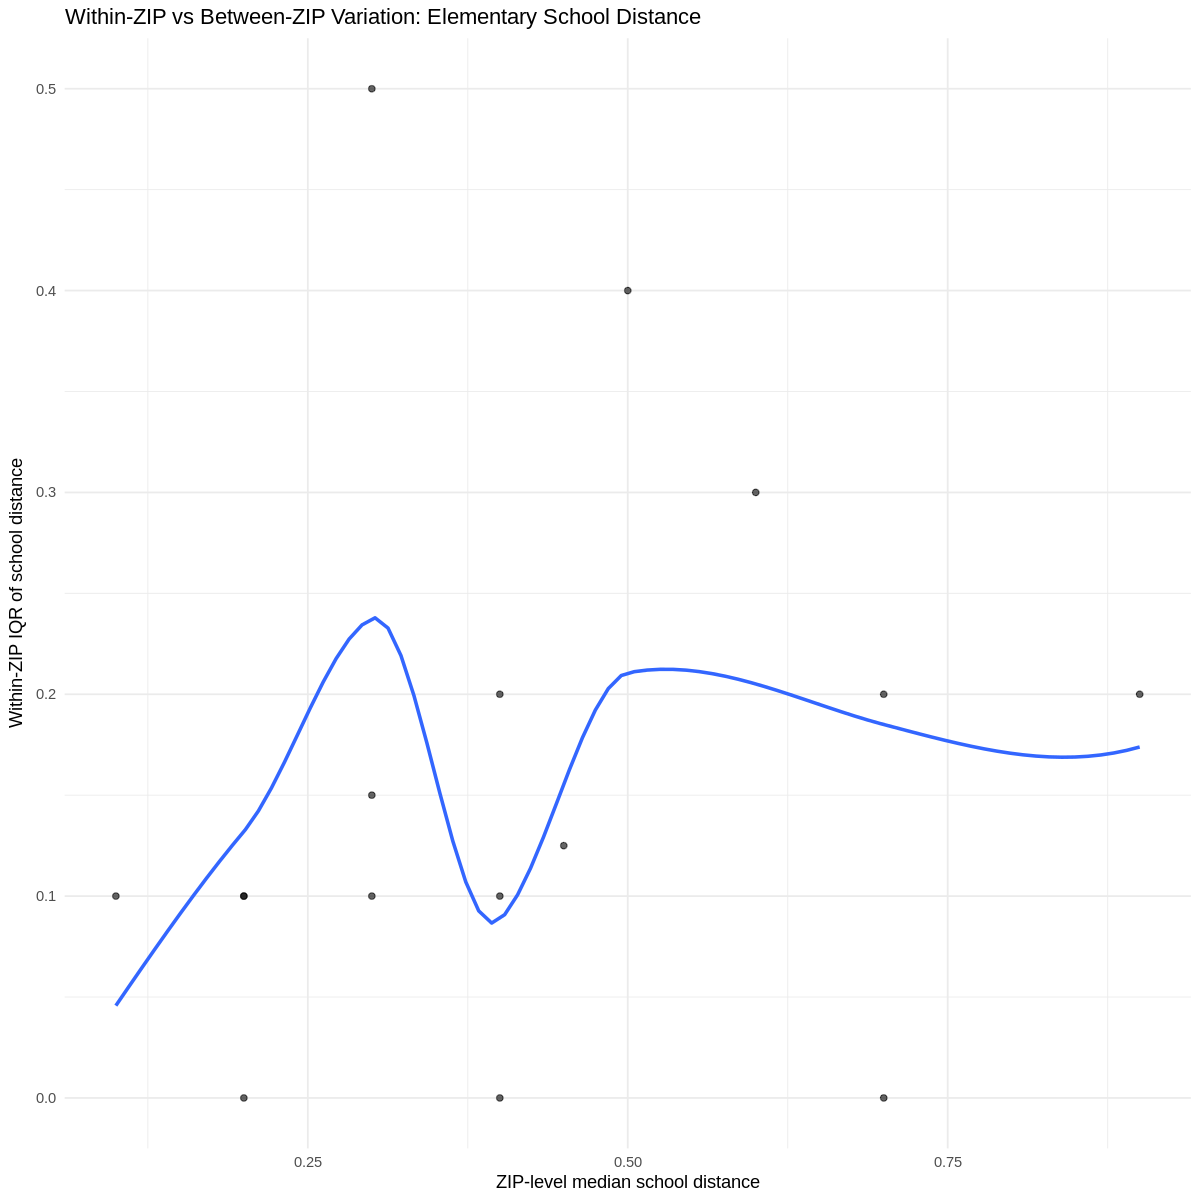

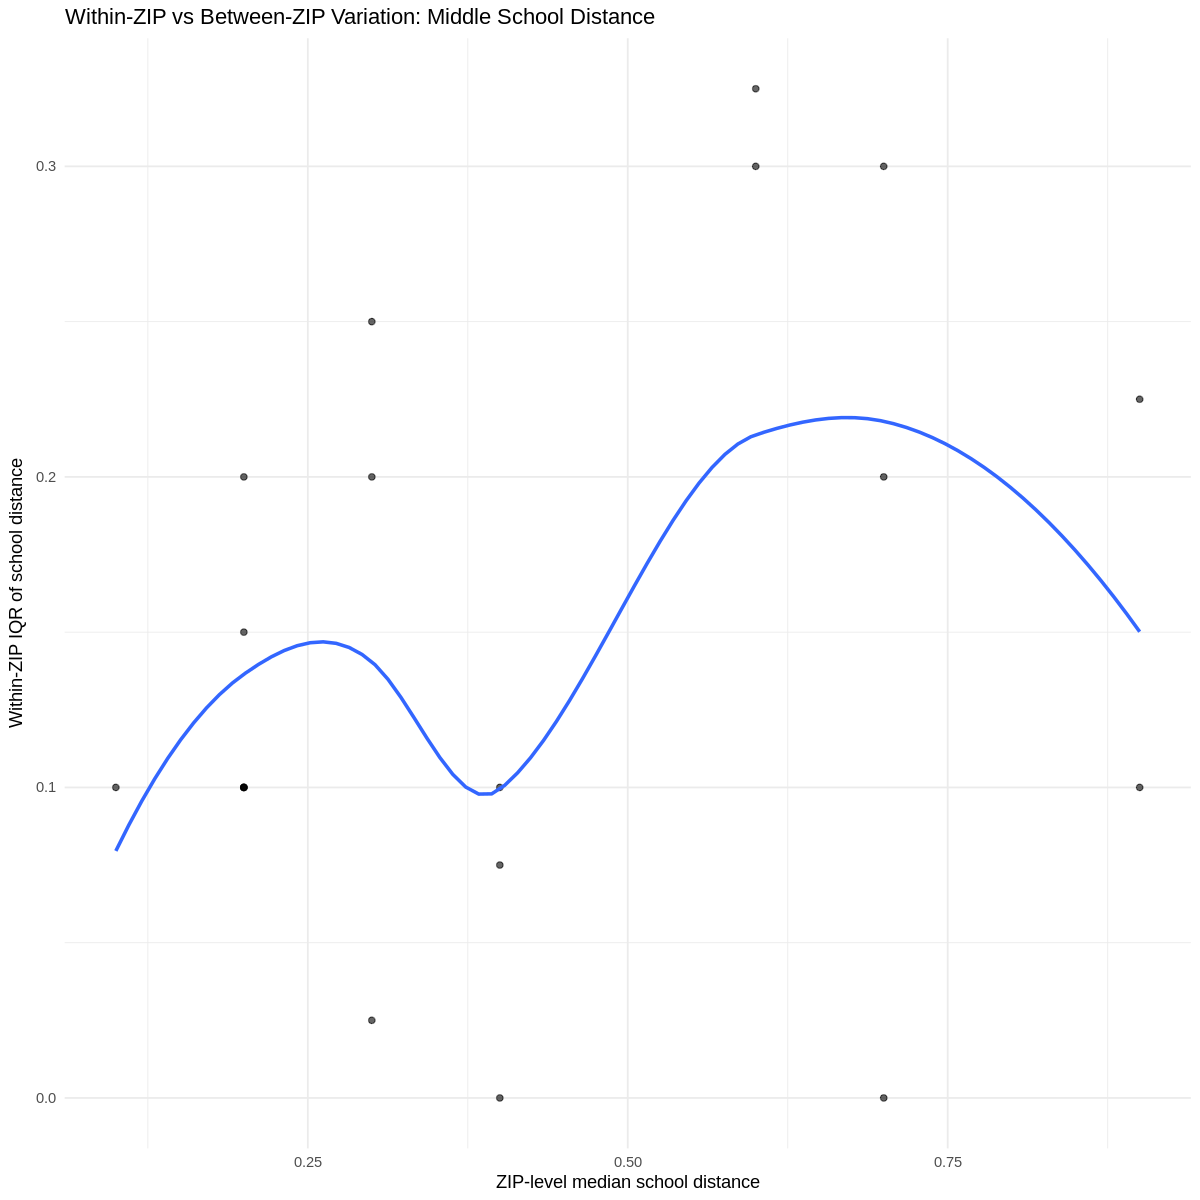

In [ ]:
## Final plot of within-zipcode variation and between-zipcode variation in elementary and middle school distances.
## The ZIP-level medians of school distance vary substantially across areas, while within-ZIP dispersion is consistently low.
## This indicates strong spatial clustering, making ZIP-level median imputation appropriate and unlikely to distort the underlying
## distribution hence we impute my medan per zipcode.

make_zip_plot <- function(data, var, title_suffix) {
  zip_stats <- data %>%
    group_by(zip_code) %>%
    summarise(
      zip_median = median(.data[[var]], na.rm = TRUE),
      zip_IQR    = IQR(.data[[var]], na.rm = TRUE),
      n_obs      = sum(!is.na(.data[[var]])),
      .groups = "drop"
    ) %>%
    filter(n_obs >= 3)  # ensure stability

  ggplot(zip_stats, aes(x = zip_median, y = zip_IQR)) +
    geom_point(alpha = 0.6) +
    geom_smooth(method = "loess", se = FALSE) +
    labs(
      title = paste("Within-ZIP vs Between-ZIP Variation:", title_suffix),
      x = "ZIP-level median school distance",
      y = "Within-ZIP IQR of school distance"
    ) +
    theme_minimal()
}

# Elementary school
p_elem <- make_zip_plot(
  merged_data,
  "elementary_school_distance",
  "Elementary School Distance"
)

# Middle school
p_middle <- make_zip_plot(
  merged_data,
  "middle_school_distance",
  "Middle School Distance"
)

# Print plots
p_elem
p_middle

##Regressions: OLS, Elastic Net and Random Forest

In [ ]:
set.seed(123)

# -----------------------------
# 1. Setup CV
# -----------------------------
K <- 5
merged_data <- merged_data %>%
  mutate(fold = sample(rep(1:K, length.out = n())))

# -----------------------------
# 2. Start CV Loop
# -----------------------------
cv_results <- lapply(1:K, function(k) {

  # Split
  train <- merged_data %>% filter(fold != k)
  test  <- merged_data %>% filter(fold == k)

  # --- Imputation Step 1: Structural ---
  struct_stats <- train %>%
    group_by(property_type) %>%
    summarise(
      beds_med = median(beds, na.rm = TRUE),
      baths_med = median(baths, na.rm = TRUE),
      sqft_med = median(sqft, na.rm = TRUE),
      age_mean = mean(age_building, na.rm = TRUE),
      .groups = "drop"
    )

  train <- train %>% left_join(struct_stats, by = "property_type") %>%
    mutate(
      beds = ifelse(is.na(beds), beds_med, beds),
      baths = ifelse(is.na(baths), baths_med, baths),
      sqft = ifelse(is.na(sqft), sqft_med, sqft),
      age_building = ifelse(is.na(age_building), age_mean, age_building)
    ) %>% select(-ends_with("_med"), -age_mean)

  test <- test %>% left_join(struct_stats, by = "property_type") %>%
    mutate(
      beds = ifelse(is.na(beds), beds_med, beds),
      baths = ifelse(is.na(baths), baths_med, baths),
      sqft = ifelse(is.na(sqft), sqft_med, sqft),
      age_building = ifelse(is.na(age_building), age_mean, age_building)
    ) %>% select(-ends_with("_med"), -age_mean)

  # --- Imputation Step 2: ZIP Level ---
  zip_stats <- train %>%
    group_by(zip_code) %>%
    summarise(
      bike_med = median(bike_score, na.rm = TRUE),
      transit_med = median(transit_score, na.rm = TRUE),
      elem_med = median(elementary_school_distance, na.rm = TRUE),
      middle_med = median(middle_school_distance, na.rm = TRUE),
      .groups = "drop"
    )

  train <- train %>% left_join(zip_stats, by = "zip_code") %>%
    mutate(
      bike_score = ifelse(is.na(bike_score), bike_med, bike_score),
      transit_score = ifelse(is.na(transit_score), transit_med, transit_score),
      elementary_school_distance = ifelse(is.na(elementary_school_distance), elem_med, elementary_school_distance),
      middle_school_distance = ifelse(is.na(middle_school_distance), middle_med, middle_school_distance)
    ) %>% select(-ends_with("_med"))

  test <- test %>% left_join(zip_stats, by = "zip_code") %>%
    mutate(
      bike_score = ifelse(is.na(bike_score), bike_med, bike_score),
      transit_score = ifelse(is.na(transit_score), transit_med, transit_score),
      elementary_school_distance = ifelse(is.na(elementary_school_distance), elem_med, elementary_school_distance),
      middle_school_distance = ifelse(is.na(middle_school_distance), middle_med, middle_school_distance)
    ) %>% select(-ends_with("_med"))

  # --- Final Numeric Fallback (The "Hole" Filler) ---
  train <- train %>% mutate(across(where(is.numeric), ~ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)))
  test  <- test %>% mutate(across(where(is.numeric), ~ifelse(is.na(.x), median(train[[cur_column()]], na.rm = TRUE), .x)))

  # --- Prepare Numeric-Only Sets for Modeling ---
  # This automatically excludes zip_code, property_type, and other text
  train_num <- train %>% select(where(is.numeric), -fold)
  test_num  <- test %>% select(colnames(train_num))

  # -----------------------------
  # 3. Fit Models
  # -----------------------------

  # A. OLS
  ols_mod <- lm(estimated_monthly_payment ~ ., data = train_num)
  preds_ols <- predict(ols_mod, newdata = test_num)
  rmse_ols <- sqrt(mean((test_num$estimated_monthly_payment - preds_ols)^2, na.rm = TRUE))

  # B. Elastic Net (alpha = 0.5)
  train_x <- as.matrix(train_num %>% select(-estimated_monthly_payment))
  train_y <- train_num$estimated_monthly_payment
  test_x  <- as.matrix(test_num %>% select(-estimated_monthly_payment))

  elnet_cv <- cv.glmnet(train_x, train_y, alpha = 0.5)
  preds_en <- as.numeric(predict(elnet_cv, newx = test_x, s = "lambda.min"))
  rmse_en  <- sqrt(mean((test_num$estimated_monthly_payment - preds_en)^2, na.rm = TRUE))

  # C. Random Forest (ntree = 100 for speed)
  rf_mod  <- randomForest(estimated_monthly_payment ~ ., data = train_num, ntree = 100)
  preds_rf <- predict(rf_mod, newdata = test_num)
  rmse_rf  <- sqrt(mean((test_num$estimated_monthly_payment - preds_rf)^2, na.rm = TRUE))

  # Return results for this fold
  data.frame(fold = k, OLS = rmse_ols, ElNet = rmse_en, RF = rmse_rf)
})

# -----------------------------
# 4. Final Comparison Results
# -----------------------------
final_comparison <- bind_rows(cv_results)

print("--- RMSE Results per Fold ---")
print(final_comparison)

print("--- Mean RMSE Summary ---")
final_comparison %>%
  summarise(across(c(OLS, ElNet, RF), list(mean = mean, sd = sd)))

Warning message in predict.lm(ols_mod, newdata = test_num):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(ols_mod, newdata = test_num):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


[1] "--- RMSE Results per Fold ---"
  fold       OLS     ElNet        RF
1    1 11655.220 10574.333  8375.950
2    2  6917.353  5738.929  4735.569
3    3 28124.589 28585.806 25481.944
4    4 15185.304 15451.303  9021.899
5    5 13294.761 12778.779 11091.392
[1] "--- Mean RMSE Summary ---"


OLS_mean,OLS_sd,ElNet_mean,ElNet_sd,RF_mean,RF_sd
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
15035.45,7932.646,14625.83,8578.543,11741.35,8016.057


mtry = 12  OOB error = 164999708 
Searching left ...
mtry = 8 	OOB error = 194811690 
-0.180679 0.01 
Searching right ...
mtry = 18 	OOB error = 163136386 
0.01129288 0.01 
mtry = 27 	OOB error = 171113988 
-0.04890143 0.01 


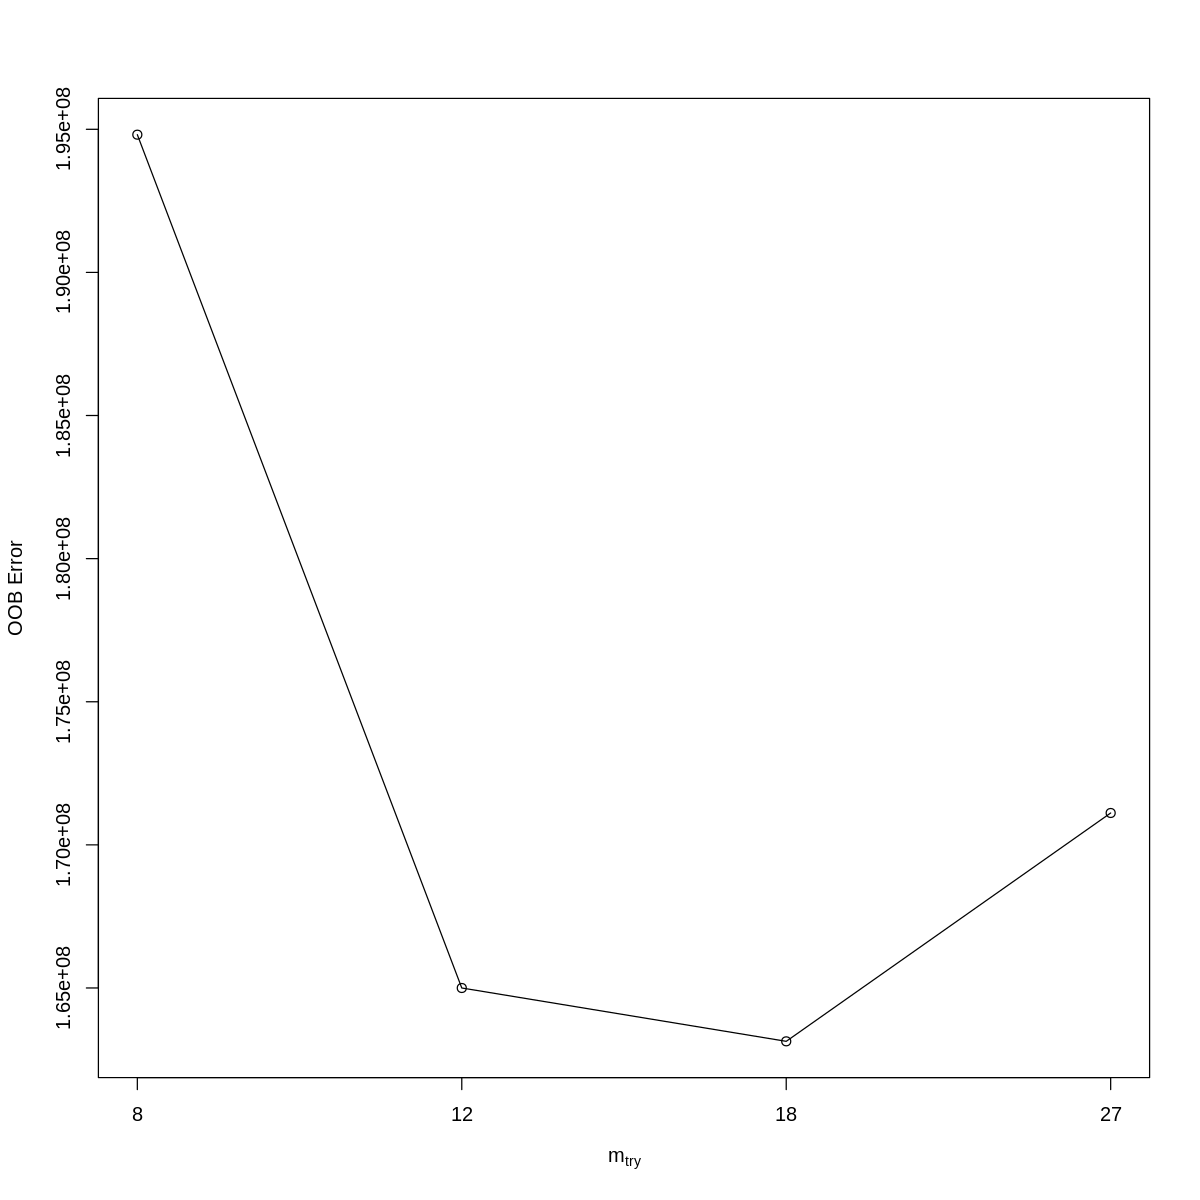

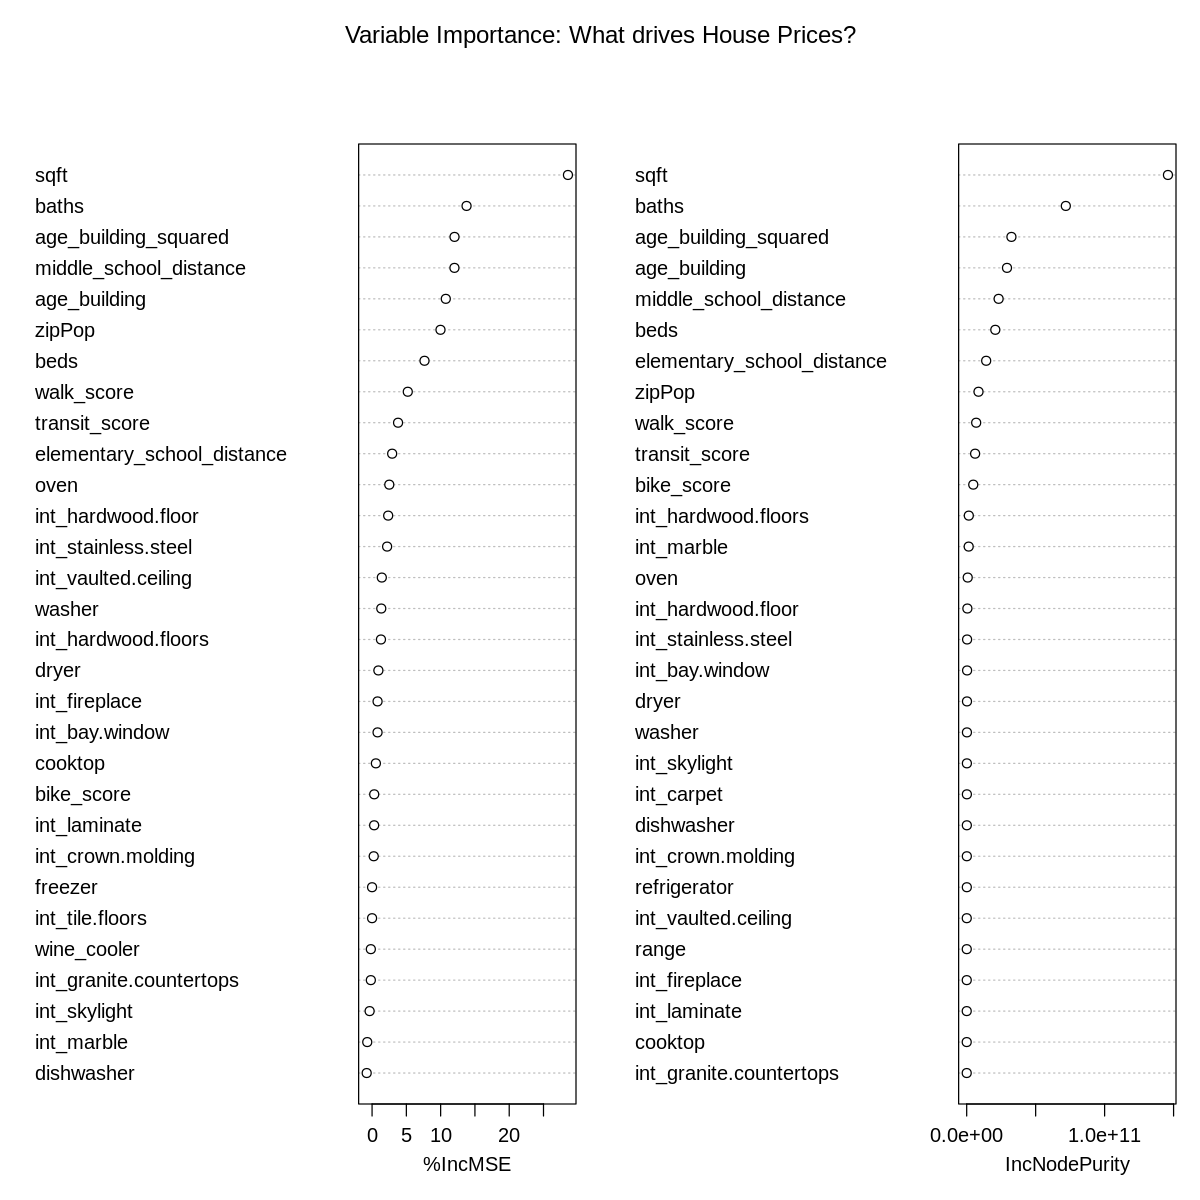

In [ ]:
# 1. Re-prepare the full data (using the same logic as the loop)
# We'll use the whole dataset for the final importance and tuning
full_train_num <- merged_data %>%
  mutate(across(where(is.numeric), ~ifelse(is.na(.x), median(.x, na.rm = TRUE), .x))) %>%
  select(where(is.numeric), -fold)

# 2. Automated Tuning for mtry
# tuneRF starts at a starting mtry and searches for the optimal value
set.seed(123)
best_mtry_search <- tuneRF(
  x = full_train_num %>% select(-estimated_monthly_payment),
  y = full_train_num$estimated_monthly_payment,
  stepFactor = 1.5,
  improve = 0.01,
  ntreeTry = 200,
  trace = TRUE,
  plot = TRUE
)

# 3. Identify the best mtry
best_mtry <- as.numeric(rownames(best_mtry_search)[which.min(best_mtry_search[,2])])

# 4. Fit the Final Optimised Model
final_rf_optimised <- randomForest(
  estimated_monthly_payment ~ .,
  data = full_train_num,
  mtry = best_mtry,
  ntree = 500, # Higher number of trees for the final publication-ready model
  importance = TRUE
)

# 5. Visualise Feature Importance (Crucial for your Master's project)
varImpPlot(final_rf_optimised, main = "Variable Importance: What drives House Prices?")

##Comments on RF above.

Unsuprisingly, square footage is by far the most important predictor for house-prices. After that, interior features such as the amount of baths and beds are also important predictors. Besides square feet and interior it seems like the age of building squared is an important predictor, likely reflecting the non-linear underlying effect where recent and old buildings can be very expensive due to modernity or due to aesthetic value. Finally, neighbourhood charactersitics like middle-school distance, zip-code population and walk- and transit-score seem important at predicting house-prices. Unexpectedly, the crime-rate per capita, which we expected to be an important predictors, does not seem to strongly predict house-prices

Elementary school distance is a better predictor than high school distance. Perhaps elementary school distance is a more granular metric. It is plausible that many elementary schools feed into only a few middle schools, thus making middle schoool distance a more important factor in families' decision-making, and affecting the price of houses through that channel.

To aid interpretability, we approximate the random forest with a shallow regression tree that captures the dominant prediction patterns.

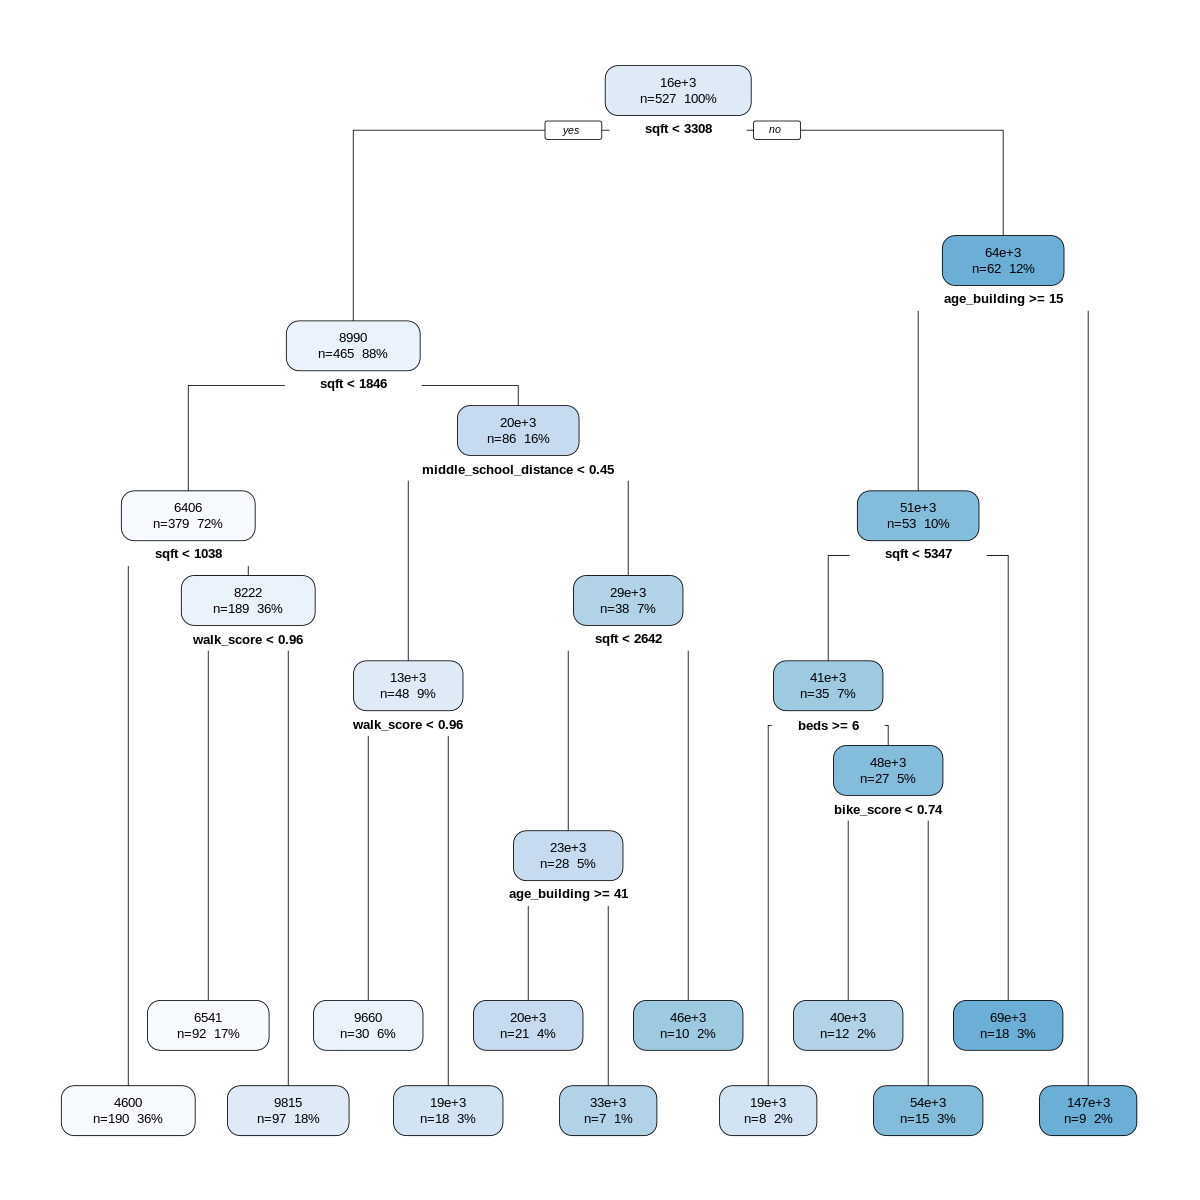

In [ ]:
# Fit a single CART tree to the SAME data
single_tree <- rpart(
  estimated_monthly_payment ~ .,
  data = full_train_num,
  method = "anova",
  control = rpart.control(cp = 0.001)
)

rpart.plot(single_tree, type = 2, extra = 101)

In [ ]:
## Export our constructed dataset to .csv
write.csv(merged_data, "FinalProjectDataset.csv", row.names = FALSE)